In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd

In [2]:
data_jan_path = "C:/DCU/Uber_pred/yellow_tripdata_2016-01.csv"
data_feb_path = "C:/DCU/Uber_pred/yellow_tripdata_2016-02.csv"
data_march_path = "C:/DCU/Uber_pred/yellow_tripdata_2016-03.csv"

In [3]:
data_jan = dd.read_csv(data_jan_path,assume_missing = True)
data_feb = dd.read_csv(data_feb_path,assume_missing = True)
data_march = dd.read_csv(data_march_path,assume_missing = True)

In [4]:
data_jan

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
npartitions=26,,,,,,,,,,,,,,,,,,,
,float64,string,string,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [5]:
print(data_jan.shape)
print(data_feb.shape)
print(data_march.shape)

(<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(63d1b5b)).size() // 19, dtype=int32>, 19)
(<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(e4ecdcd)).size() // 19, dtype=int32>, 19)
(<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(8baa143)).size() // 19, dtype=int32>, 19)


In [6]:
data_final = dd.concat([data_jan,data_feb,data_march], axis = 0).drop(columns = ['extra','mta_tax','tip_amount','tolls_amount','improvement_surcharge','total_amount','payment_type'])

In [7]:
data_final

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount
npartitions=82,,,,,,,,,,,,
,float64,string,string,float64,float64,float64,float64,float64,string,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...


In [8]:
data_final.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'],
      dtype='object')

In [9]:
data_final.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount
0,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,2.0,1.10,-73.990372,40.734695,1.0,N,-73.981842,40.732407,7.5
1,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,5.0,4.90,-73.980782,40.729912,1.0,N,-73.944473,40.716679,18.0
2,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,10.54,-73.984550,40.679565,1.0,N,-73.950272,40.788925,33.0
3,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,4.75,-73.993469,40.718990,1.0,N,-73.962242,40.657333,16.5
4,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,3.0,1.76,-73.960625,40.781330,1.0,N,-73.977264,40.758514,8.0


In [10]:
data_final.isnull().sum().compute()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
fare_amount              0
dtype: int64

In [11]:
data_final.nunique().compute()

VendorID                       2
tpep_pickup_datetime     7130690
tpep_dropoff_datetime    7139647
passenger_count               10
trip_distance               5586
pickup_longitude           44505
pickup_latitude            73706
RatecodeID                     7
store_and_fwd_flag             2
dropoff_longitude          71576
dropoff_latitude          102017
fare_amount                 3228
dtype: int64

In [12]:
data_final.describe().compute()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,fare_amount
count,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07
mean,1.532576e+00,1.661700e+00,5.309408e+00,-7.283942e+01,4.012605e+01,1.039150e+00,-7.290482e+01,4.016297e+01,1.257198e+01
std,4.989377e-01,1.316154e+00,4.672575e+03,9.090656e+00,5.007832e+00,5.564537e-01,8.828348e+00,4.863875e+00,9.179006e+01
min,1.000000e+00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-1.616987e+02,-7.703949e+01,-9.576000e+02
25%,1.000000e+00,1.000000e+00,1.100000e+00,-7.399055e+01,4.074137e+01,1.000000e+00,-7.399009e+01,4.074001e+01,7.000000e+00
50%,2.000000e+00,1.000000e+00,1.930000e+00,-7.397922e+01,4.075640e+01,1.000000e+00,-7.397832e+01,4.075612e+01,1.000000e+01
75%,2.000000e+00,2.000000e+00,3.800000e+00,-7.396252e+01,4.076979e+01,1.000000e+00,-7.395599e+01,4.077166e+01,1.550000e+01
max,2.000000e+00,9.000000e+00,1.907263e+07,9.464387e+01,6.685682e+01,9.900000e+01,3.889659e+01,4.053167e+02,4.294967e+05


In [13]:
vendor_share = (
    data_final['VendorID'].value_counts(normalize = True)
    .compute()
)

In [14]:
vendor_share

VendorID
2.0    0.532576
1.0    0.467424
Name: proportion, dtype: float64

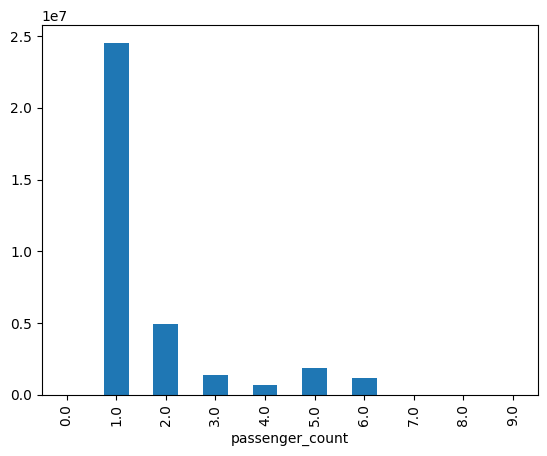

In [15]:
passenger_count = data_final['passenger_count'].value_counts().compute()
passenger_count.sort_index().plot(kind = "bar")
plt.show()

ConversionError: Failed to convert value(s) to axis units: 0            
1            
2            
3            
4            
           ..
34499854     
34499855     
34499856     
34499857     
34499858     
Name: x, Length: 34499859, dtype: object

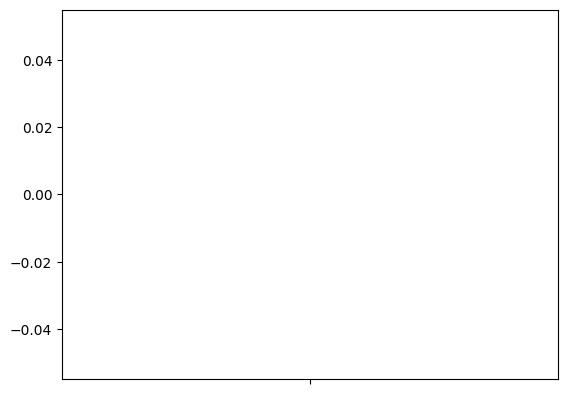

In [16]:
sns.boxplot(data_final.loc[:,'trip_distance'].compute())

In [45]:
percentile_values = np.arange(0.1,1.0,0.1)
percentile_values

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [ ]:
for percentile in percentile_values:
    print(f"The Trip distance value for{int(percentile * 100)}th percentile is {data_final['trip_distance'].quantile(q = percentile).compute()}")

The Trip distance value for10th percentile is 0.7
The Trip distance value for20th percentile is 0.97
The Trip distance value for30th percentile is 1.23
The Trip distance value for40th percentile is 1.56
The Trip distance value for50th percentile is 1.93


In [18]:
sns.boxplot(data_final.loc[:,"fare_amount"].compute())

MemoryError: 

# RateCodeID